In [15]:
from pathlib import Path

import matplotlib
import pandas as pd

# matplotlib.use("Agg")

# Add the directory containing script.py to the Python path
import os
import sys

from matplotlib import pyplot as plt

utils_path = os.path.abspath("./src/")
if utils_path not in sys.path:
    sys.path.append(utils_path)

In [2]:
OUTPUT_N_1_DIR = Path("./demo_outputs_fallspring/nitrogen_3layer_scenarios/tiles_adsorption")
OUTPUT_N_2_DIR = Path("./demo_outputs_spring/nitrogen_3layer_scenarios/tiles_adsorption")

OUTPUT_F_1_DIR = Path("./demo_outputs_fallspring/hydrology_3layer/tiles")
OUTPUT_F_2_DIR = Path("./demo_outputs_spring/hydrology_3layer/tiles")

filename_nitrogen_results_1 = OUTPUT_N_1_DIR / "nitrogen_solution.parquet"
filename_nitrogen_results_2 = OUTPUT_N_2_DIR / "nitrogen_solution.parquet"

filename_fluxes_results_1 = OUTPUT_F_1_DIR / "fluxes1.parquet"
filename_fluxes_results_2 = OUTPUT_F_2_DIR / "fluxes1.parquet"

In [3]:
df_nitrogen_results_1 = pd.read_parquet(filename_nitrogen_results_1)
df_nitrogen_results_2 = pd.read_parquet(filename_nitrogen_results_2)
df_nitrogen_results_1['doy'] = df_nitrogen_results_1.time.dt.dayofyear
df_nitrogen_results_2['doy'] = df_nitrogen_results_2.time.dt.dayofyear

df_fluxes_results_1 = pd.read_parquet(filename_fluxes_results_1)
df_fluxes_results_1['doy'] = df_fluxes_results_1.time.dt.dayofyear
df_fluxes_results_2 = pd.read_parquet(filename_fluxes_results_2)
df_fluxes_results_2['doy'] = df_fluxes_results_2.time.dt.dayofyear


In [4]:
df_1 = df_nitrogen_results_1.merge(df_fluxes_results_1, on="time", how="left")
df_1.drop(columns=["doy_x"], inplace=True)
df_1.rename(columns={"doy_y": "doy"}, inplace=True)

df_2 = df_nitrogen_results_2.merge(df_fluxes_results_2, on="time", how="left")
df_2.drop(columns=["doy_x"], inplace=True)
df_2.rename(columns={"doy_y": "doy"}, inplace=True)

df_1["landscape_load"] = 24*3600*1e3*(df_1["soil_c_din"] * df_1["q_sc"] + df_1["gwa_c_din"] * df_1["q_gwac"]+ df_1["gwa_c_din"] * df_1["q_gwatd"] + df_1["gwp_c_din"]* df_1["q_gwpc"])
df_2["landscape_load"] = 24*3600*1e3*(df_2["soil_c_din"] * df_2["q_sc"] + df_2["gwa_c_din"] * df_2["q_gwac"]+ df_2["gwa_c_din"] * df_2["q_gwatd"] + df_2["gwp_c_din"]* df_2["q_gwpc"])

In [5]:
df_nitrogen_results_1_avg_by_doy = (
    df_1.groupby("doy", as_index=False).mean(numeric_only=True)
)

df_nitrogen_results_1_min_by_doy = (
    df_1.groupby("doy", as_index=False).min(numeric_only=True)
)

df_nitrogen_results_1_max_by_doy = (
    df_1.groupby("doy", as_index=False).max(numeric_only=True)
)

df_nitrogen_results_2_avg_by_doy = (
    df_2.groupby("doy", as_index=False).mean(numeric_only=True)
)

df_nitrogen_results_2_min_by_doy = (
    df_2.groupby("doy", as_index=False).min(numeric_only=True)
)   

df_nitrogen_results_2_max_by_doy = (
    df_2.groupby("doy", as_index=False).max(numeric_only=True)
)

In [14]:
mass_fallspring = df_nitrogen_results_1_avg_by_doy.landscape_load.sum()
mass_spring = df_nitrogen_results_2_avg_by_doy.landscape_load.sum()

print(f"Total DIN load for Scenario fallspring: {mass_fallspring:.0f}")
print(f"Total DIN load for Scenario spring: {mass_spring:.0f}")
print(f"Total DIN load difference between scenarios: {(mass_fallspring - mass_spring)/mass_fallspring*100:.1f}")

Total DIN load for Scenario fallspring: 9804
Total DIN load for Scenario spring: 9283
Total DIN load difference between scenarios: 5.3


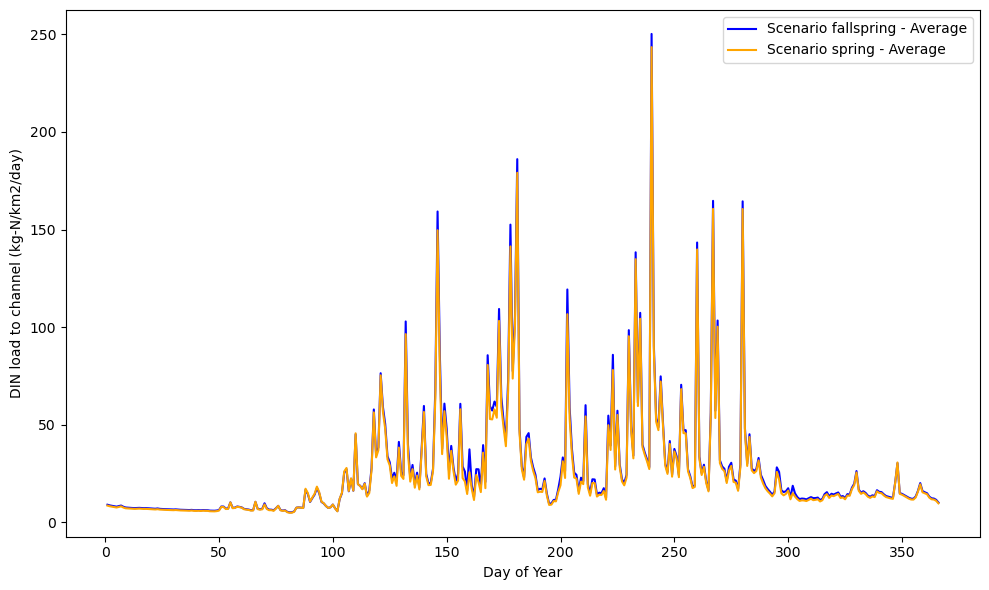

In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

# ax.fill_between(
#     df_nitrogen_results_1_avg_by_doy.doy,
#     df_nitrogen_results_1_min_by_doy.landscape_load,
#     df_nitrogen_results_1_max_by_doy.landscape_load,
#     color="blue",
#     alpha=0.2,
#     label="Scenario 1 Range",
# )

# ax.fill_between(
#     df_nitrogen_results_2_avg_by_doy.doy,
#     df_nitrogen_results_2_min_by_doy.landscape_load,
#     df_nitrogen_results_2_max_by_doy.landscape_load,
#     color="orange",
#     alpha=0.2,
#     label="Scenario 2 Range",
# )

ax.plot(
    df_nitrogen_results_1_avg_by_doy.doy,
    df_nitrogen_results_1_avg_by_doy.landscape_load,
    color="blue",
    label="Scenario fallspring - Average",
)

ax.plot(
    df_nitrogen_results_2_avg_by_doy.doy,
    df_nitrogen_results_2_avg_by_doy.landscape_load,
    color="orange",
    label="Scenario spring - Average",
)
ax.set_xlabel("Day of Year")
ax.set_ylabel("DIN load to channel (kg-N/km2/day)")
ax.legend()
plt.tight_layout()

plt.show()